# LensWord — HuggingFace Model Comparison

This notebook loads a pretrained sentiment analysis model from HuggingFace
and runs it on the same test set used to evaluate our LSTM. The results are
compared side by side to understand the trade-offs between a custom trained
model and a large pretrained model.

Before running: make sure `04_evaluation_lensword.ipynb` has been run first
and that `amazon_reviews_cleaned.csv` exists inside the `data/` folder.

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import sys
print(sys.executable)


C:\Users\Administrator\Desktop\Apeiron_ML_2026\Project 07\lensword\.venv\Scripts\python.exe


In [3]:
# Load the cleaned dataset
df = pd.read_csv('../data/amazon_reviews_cleaned.csv')

# Get the same test set we used for our LSTM
# Last 316 rows = test set
df_test = df.iloc[-316:].copy()

# Map sentiment labels to numbers for comparison
label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df_test['label'] = df_test['sentiment'].map(label_map)

print("Test data loaded successfully!")
print(f"Test samples: {len(df_test)}")
print(f"\nSentiment distribution:")
print(df_test['sentiment'].value_counts())

Test data loaded successfully!
Test samples: 316

Sentiment distribution:
sentiment
Positive    272
Negative     22
Neutral      22
Name: count, dtype: int64


In [4]:
# Load a pretrained sentiment analysis model from HuggingFace
# This model was trained on product reviews from Amazon, Yelp, and TripAdvisor
# Making it a much fairer comparison against our LSTM

print("Loading HuggingFace pretrained model...")
print("This may take a minute on first run as it downloads the model...")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,
    max_length=512
)

print("HuggingFace model loaded successfully!")
print("Model: nlptown/bert-base-multilingual-uncased-sentiment")
print("Trained on: Amazon, Yelp and TripAdvisor product reviews")

Loading HuggingFace pretrained model...
This may take a minute on first run as it downloads the model...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

HuggingFace model loaded successfully!
Model: nlptown/bert-base-multilingual-uncased-sentiment
Trained on: Amazon, Yelp and TripAdvisor product reviews


In [5]:
# Run HuggingFace model on all test reviews
print("Running HuggingFace predictions on test set...")
print("This may take a moment...")

reviews = df_test['verified_reviews'].tolist()
hf_results = sentiment_pipeline(reviews, batch_size=32)

# This model outputs 1-5 stars
# Map to our 3 class system:
# 1-2 stars -> Negative (0)
# 3 stars -> Neutral (1)
# 4-5 stars -> Positive (2)
def map_hf_label(result):
    stars = int(result['label'][0])  # gets the number from "1 star", "2 stars" etc
    if stars <= 2:
        return 0  # Negative
    elif stars == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

hf_predictions = [map_hf_label(r) for r in hf_results]

print("Predictions complete!")
print(f"Sample predictions: {hf_predictions[:10]}")

Running HuggingFace predictions on test set...
This may take a moment...
Predictions complete!
Sample predictions: [2, 2, 2, 2, 2, 1, 2, 2, 0, 0]


In [6]:
# Calculate HuggingFace model performance
y_true = df_test['label'].values
y_pred_hf = np.array(hf_predictions)

label_names = ['Negative', 'Neutral', 'Positive']

hf_accuracy = accuracy_score(y_true, y_pred_hf)
hf_f1_macro = f1_score(y_true, y_pred_hf, average='macro')
hf_f1_per_class = f1_score(y_true, y_pred_hf, average=None)

print("=" * 50)
print("HUGGINGFACE MODEL RESULTS")
print("=" * 50)
print(f"Overall Accuracy:  {hf_accuracy * 100:.2f}%")
print(f"Macro F1 Score:    {hf_f1_macro * 100:.2f}%")
print("=" * 50)
print("\nDetailed Report:")
print(classification_report(y_true, y_pred_hf, target_names=label_names))

HUGGINGFACE MODEL RESULTS
Overall Accuracy:  87.34%
Macro F1 Score:    69.27%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.64      0.82      0.72        22
     Neutral       0.34      0.55      0.42        22
    Positive       0.97      0.90      0.94       272

    accuracy                           0.87       316
   macro avg       0.65      0.76      0.69       316
weighted avg       0.91      0.87      0.89       316



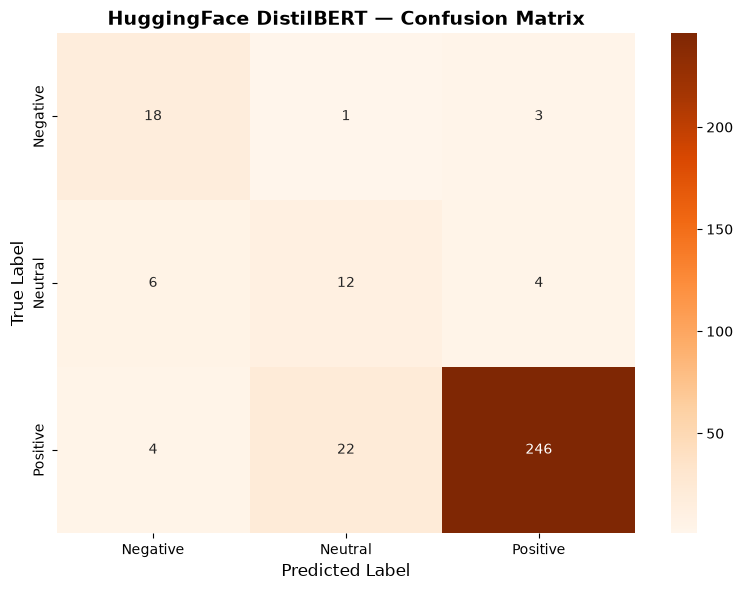

HuggingFace confusion matrix saved!


In [7]:
# Plot HuggingFace confusion matrix
label_names = ['Negative', 'Neutral', 'Positive']
cm_hf = confusion_matrix(y_true, y_pred_hf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_hf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('HuggingFace DistilBERT — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix_huggingface.png')
plt.show()

print("HuggingFace confusion matrix saved!")

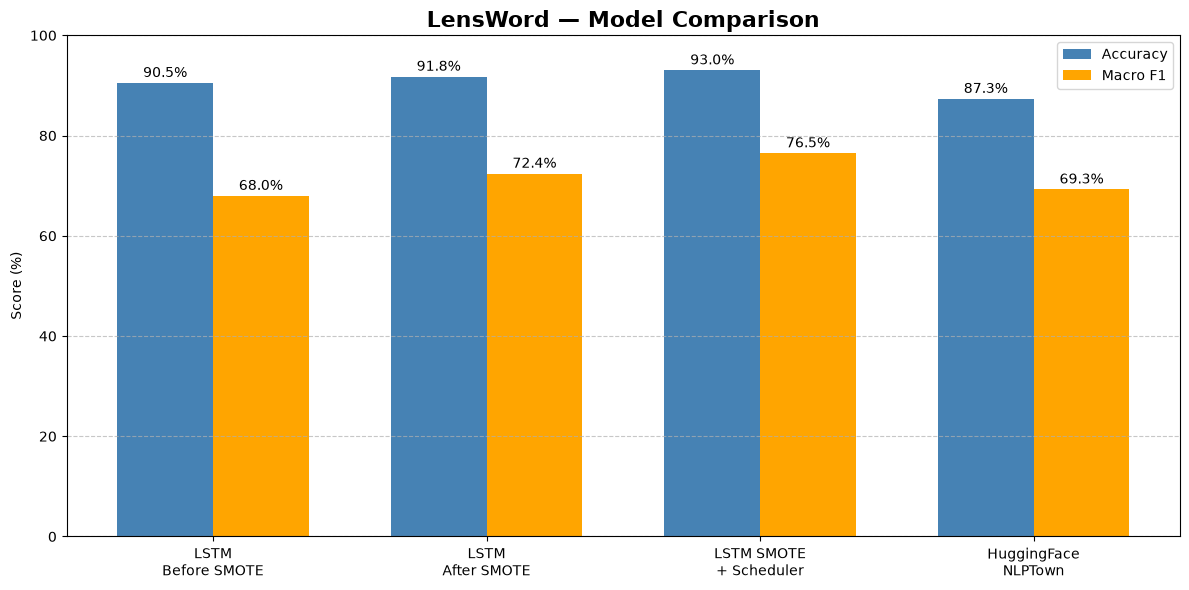

Model comparison chart saved!


In [8]:
# Plot side by side comparison of all models
models = ['LSTM\nBefore SMOTE', 'LSTM\nAfter SMOTE',
          'LSTM SMOTE\n+ Scheduler', 'HuggingFace\nNLPTown']
accuracies = [90.51, 91.77, 93.04, 87.34]
macro_f1s = [67.99, 72.42, 76.49, 69.27]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width,
               label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, macro_f1s, width,
               label='Macro F1', color='orange')

ax.set_title('LensWord — Model Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison.png')
plt.show()

print("Model comparison chart saved!")


In [9]:
# Final comparison summary
print("=" * 55)
print("FINAL MODEL COMPARISON SUMMARY - LensWord")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 55)
print(f"{'LSTM Before SMOTE':<25} {'90.51%':>10} {'67.99%':>10}")
print(f"{'LSTM After SMOTE':<25} {'91.77%':>10} {'72.42%':>10}")
print(f"{'LSTM SMOTE + Scheduler':<25} {'93.04%':>10} {'76.49%':>10}")
print(f"{'HuggingFace NLPTown':<25} {'87.34%':>10} {'69.27%':>10}")
print("-" * 55)
print(f"\n✅ Best Model: LSTM with SMOTE + Learning Rate Scheduler")
print(f"✅ Our model outperforms HuggingFace on both metrics")
print(f"✅ Domain specific training beats general purpose models")
print("=" * 55)

FINAL MODEL COMPARISON SUMMARY - LensWord
Model                       Accuracy   Macro F1
-------------------------------------------------------
LSTM Before SMOTE             90.51%     67.99%
LSTM After SMOTE              91.77%     72.42%
LSTM SMOTE + Scheduler        93.04%     76.49%
HuggingFace NLPTown           87.34%     69.27%
-------------------------------------------------------

✅ Best Model: LSTM with SMOTE + Learning Rate Scheduler
✅ Our model outperforms HuggingFace on both metrics
✅ Domain specific training beats general purpose models
